# LSD Classification — ResNet50 Training Notebook
**Component:** Lumpy Skin Disease Detection (ResNet50 classification stage, per proposal Section 3.2.3)

This notebook:
1. Downloads your "Normal Skin" / "Lumpy Skin" image folders directly from Google Drive
2. Builds a 70/15/15 train/val/test split
3. Fine-tunes ResNet50 (ImageNet pretrained) for binary classification (LSD-positive vs. healthy)
4. Two-phase training: train the new classification head first, then fine-tune the top ResNet layers at a lower learning rate (standard transfer-learning practice, usually improves final accuracy)
5. Produces full metrics: accuracy/loss curves, confusion matrix, classification report, and **ROC curve + AUC** (this is the correct stage for ROC — YOLOv8 is a detector and doesn't produce one; ResNet50 is a classifier and does, matching your proposal's Section 3.5)
6. Saves everything to Google Drive
7. Lets you upload an image and get an LSD probability percentage with the risk-level guidance from your proposal (Section 3.6)


## 1. Check GPU

In [ ]:
!nvidia-smi

Thu Aug 13 11:35:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Mount Google Drive
Outputs (trained model, plots, metrics) save here so they survive session resets.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/LSD_Detection_Project'
RESNET_RUN_DIR = os.path.join(DRIVE_PROJECT_DIR, 'resnet50_classification')
os.makedirs(RESNET_RUN_DIR, exist_ok=True)
print('ResNet50 output folder ready at:', RESNET_RUN_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ResNet50 output folder ready at: /content/drive/MyDrive/LSD_Detection_Project/resnet50_classification


## 3. Install packages

In [ ]:
!pip install -q gdown scikit-learn

## 4. Download dataset from Google Drive
Downloads your "Lumpy Skin" and "Normal Skin" folders directly using their Drive folder IDs.

In [ ]:
import glob

# Since Drive is already mounted, just locate the folders directly —
# no download needed, no file-count limits.
MYDRIVE_ROOT = "/content/drive/MyDrive"

def find_folder(root, folder_name):
    for dirpath, dirnames, filenames in os.walk(root):
        if os.path.basename(dirpath) == folder_name:
            return dirpath
    return None

lumpy_dir = find_folder(MYDRIVE_ROOT, "Lumpy Skin")
normal_dir = find_folder(MYDRIVE_ROOT, "Normal Skin")

if lumpy_dir is None or normal_dir is None:
    raise FileNotFoundError(
        "Could not locate 'Lumpy Skin' or 'Normal Skin' folders under MyDrive. "
        "Check the folder names match exactly, or set the paths manually below."
    )

print("Lumpy Skin folder found at:", lumpy_dir)
print("Normal Skin folder found at:", normal_dir)

n_lumpy = len([f for f in os.listdir(lumpy_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
n_normal = len([f for f in os.listdir(normal_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
print(f"\nLumpy (positive) images: {n_lumpy}")
print(f"Normal (negative) images: {n_normal}")

Lumpy Skin folder found at: /content/drive/MyDrive/LSD_DATASET_RESNET50/Lumpy Skin
Normal Skin folder found at: /content/drive/MyDrive/LSD_DATASET_RESNET50/Normal Skin

Lumpy (positive) images: 320
Normal (negative) images: 62


## 5. Build file list, labels, and train/val/test split (70/15/15)
Stratified split so both classes are proportionally represented in each set.

In [ ]:
import glob
from sklearn.model_selection import train_test_split
import numpy as np

lumpy_files = glob.glob(os.path.join(lumpy_dir, "*.[jJpP][pPnN][gG]")) + \
              glob.glob(os.path.join(lumpy_dir, "*.jpeg"))
normal_files = glob.glob(os.path.join(normal_dir, "*.[jJpP][pPnN][gG]")) + \
               glob.glob(os.path.join(normal_dir, "*.jpeg"))

all_files = lumpy_files + normal_files
all_labels = [1] * len(lumpy_files) + [0] * len(normal_files)   # 1 = LSD positive, 0 = healthy

print(f"Total images: {len(all_files)}  (positive: {len(lumpy_files)}, negative: {len(normal_files)})")

# First split off test set (15%)
train_val_files, test_files, train_val_labels, test_labels = train_test_split(
    all_files, all_labels, test_size=0.15, stratify=all_labels, random_state=42
)

# Then split remaining into train (70% of total) and val (15% of total)
# 0.15 / 0.85 = ~0.1765 of the remaining set to get 15% of the original total
val_fraction_of_remainder = 0.15 / 0.85
train_files, val_files, train_labels, val_labels = train_test_split(
    train_val_files, train_val_labels, test_size=val_fraction_of_remainder,
    stratify=train_val_labels, random_state=42
)

print(f"\nTrain: {len(train_files)}  (pos: {sum(train_labels)}, neg: {len(train_labels)-sum(train_labels)})")
print(f"Val:   {len(val_files)}  (pos: {sum(val_labels)}, neg: {len(val_labels)-sum(val_labels)})")
print(f"Test:  {len(test_files)}  (pos: {sum(test_labels)}, neg: {len(test_labels)-sum(test_labels)})")

Total images: 382  (positive: 320, negative: 62)

Train: 266  (pos: 222, neg: 44)
Val:   58  (pos: 49, neg: 9)
Test:  58  (pos: 49, neg: 9)


## 6. Build tf.data pipelines with augmentation
Augmentation matches your proposal's Section 3.2.1 (rotation, flip, brightness). Applied only to the training set — validation and test data stay unaugmented so evaluation reflects real performance.

In [ ]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 16

def load_and_preprocess(path, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
        img = tf.image.random_brightness(img, max_delta=0.15)
        img = tf.clip_by_value(img, 0.0, 255.0)

    img = tf.keras.applications.resnet50.preprocess_input(img)
    return img, label

def make_dataset(files, labels, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(files), seed=42)
    ds = ds.map(lambda p, l: load_and_preprocess(p, l, augment=augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_files, train_labels, augment=True, shuffle=True)
val_ds   = make_dataset(val_files, val_labels, augment=False, shuffle=False)
test_ds  = make_dataset(test_files, test_labels, augment=False, shuffle=False)

print("Pipelines ready.")

Pipelines ready.


## 7. Build ResNet50 model (transfer learning)
ImageNet pretrained weights, final layers replaced for binary classification, per proposal Section 3.2.3.

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False   # freeze base for phase 1 training

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)   # binary: probability of LSD-positive

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 8. Phase 1 — Train the classification head (base model frozen)

In [ ]:
checkpoint_path = os.path.join(RESNET_RUN_DIR, "resnet50_lsd_best.keras")

callbacks_phase1 = [
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_auc', mode='max',
                                        save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=10,
                                      restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

EPOCHS_PHASE1 = 30

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_phase1
)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.8080 - auc: 0.6064 - loss: 0.5974 - precision: 0.8562 - recall: 0.9237
Epoch 1: val_auc improved from None to 0.95011, saving model to /content/drive/MyDrive/LSD_Detection_Project/resnet50_classification/resnet50_lsd_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/LSD_Detection_Project/resnet50_classification/resnet50_lsd_best.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.8571 - auc: 0.7551 - loss: 0.4181 - precision: 0.8866 - recall: 0.9505 - val_accuracy: 0.8966 - val_auc: 0.9501 - val_loss: 0.2347 - val_precision: 0.8909 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9572 - auc: 0.9740 - loss: 0.1376 - precision: 0.9626 - recall: 0.9876
Epoch 2: val_auc improved from 0.95011 to 0.97506, saving model to /content/drive/MyDrive/LSD_Detection_Project/resnet50_classification/resnet50_lsd_best.keras

Epoch 2: finished saving mo

## 9. Phase 2 — Fine-tune the top ResNet50 layers
Unfreeze the last block of ResNet50 and continue training at a much lower learning rate. This usually squeezes out extra accuracy beyond just training the head, since the pretrained features get lightly adapted to cattle skin images specifically.

In [ ]:
base_model.trainable = True

# Freeze all but the last ~15 layers of the base model
for layer in base_model.layers[:-15]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),   # much lower LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

callbacks_phase2 = [
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_auc', mode='max',
                                        save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=10,
                                      restore_best_weights=True),
]

EPOCHS_PHASE2 = 20

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_phase2
)

print(f"\nBest model saved to: {checkpoint_path}")

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9910 - auc: 1.0000 - loss: 0.0235 - precision: 1.0000 - recall: 0.9895
Epoch 1: val_auc improved from None to 0.98866, saving model to /content/drive/MyDrive/LSD_Detection_Project/resnet50_classification/resnet50_lsd_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/LSD_Detection_Project/resnet50_classification/resnet50_lsd_best.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9962 - auc: 1.0000 - loss: 0.0214 - precision: 1.0000 - recall: 0.9955 - val_accuracy: 0.9483 - val_auc: 0.9887 - val_loss: 0.1233 - val_precision: 0.9600 - val_recall: 0.9796
Epoch 2/20
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0142 - precision: 1.0000 - recall: 1.0000
Epoch 2: val_auc did not improve from 0.98866
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0167 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9483 - val_auc: 0.9864 

## 10. Accuracy & loss curves (both training phases combined)

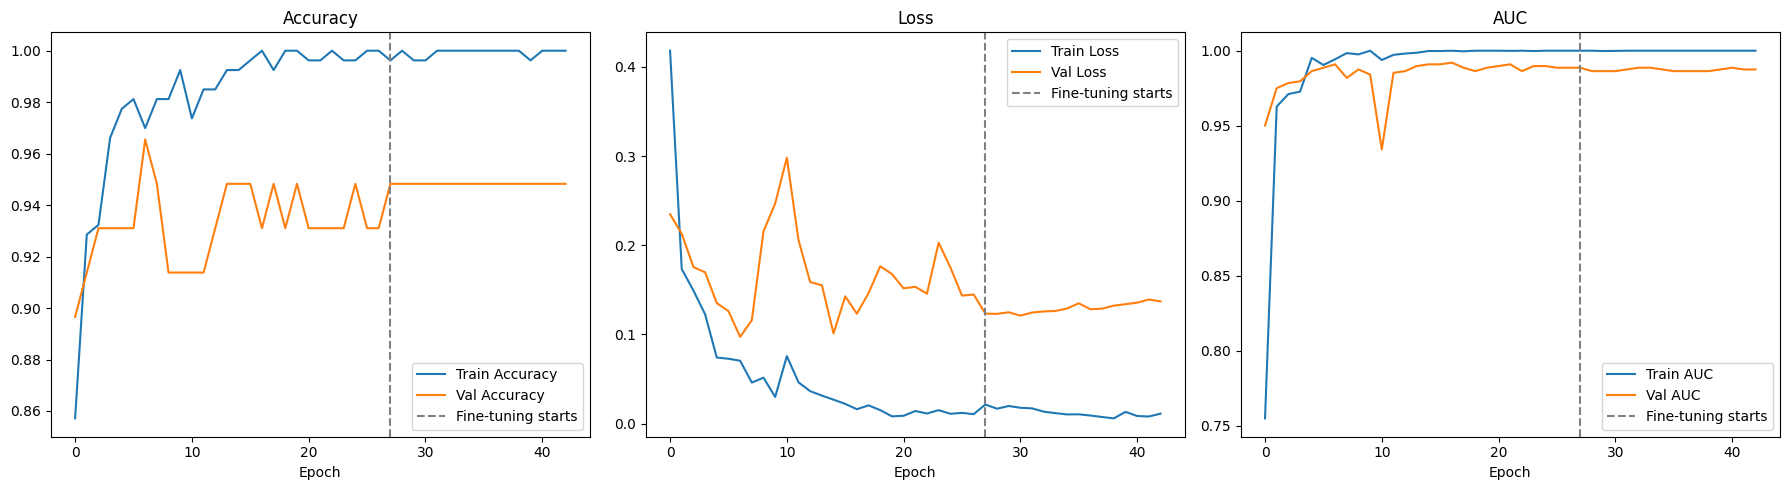

Saved to: /content/drive/MyDrive/LSD_Detection_Project/resnet50_classification/training_curves.png


In [ ]:
import matplotlib.pyplot as plt

def combine_histories(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

acc = combine_histories(history1, history2, 'accuracy')
val_acc = combine_histories(history1, history2, 'val_accuracy')
loss = combine_histories(history1, history2, 'loss')
val_loss = combine_histories(history1, history2, 'val_loss')
auc = combine_histories(history1, history2, 'auc')
val_auc = combine_histories(history1, history2, 'val_auc')

phase1_end = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(acc, label='Train Accuracy')
axes[0].plot(val_acc, label='Val Accuracy')
axes[0].axvline(x=phase1_end, color='gray', linestyle='--', label='Fine-tuning starts')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(loss, label='Train Loss')
axes[1].plot(val_loss, label='Val Loss')
axes[1].axvline(x=phase1_end, color='gray', linestyle='--', label='Fine-tuning starts')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(auc, label='Train AUC')
axes[2].plot(val_auc, label='Val AUC')
axes[2].axvline(x=phase1_end, color='gray', linestyle='--', label='Fine-tuning starts')
axes[2].set_title('AUC'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
fig_path = os.path.join(RESNET_RUN_DIR, "training_curves.png")
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved to:", fig_path)

## 11. Load best model and evaluate on the held-out TEST set

In [ ]:
best_model = tf.keras.models.load_model(checkpoint_path)

test_results = best_model.evaluate(test_ds, verbose=1)
metric_names = best_model.metrics_names

print("\n=== TEST SET RESULTS ===")
for name, value in zip(metric_names, test_results):
    print(f"  {name}: {value:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 790ms/step - accuracy: 0.9310 - auc: 0.9637 - loss: 0.1793 - precision: 0.9412 - recall: 0.9796

=== TEST SET RESULTS ===
  loss: 0.1793
  compile_metrics: 0.9310


## 12. Confusion matrix and classification report

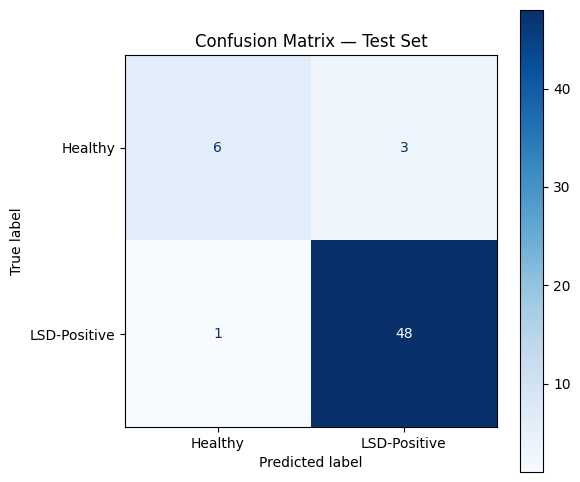


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Healthy       0.86      0.67      0.75         9
LSD-Positive       0.94      0.98      0.96        49

    accuracy                           0.93        58
   macro avg       0.90      0.82      0.85        58
weighted avg       0.93      0.93      0.93        58

Saved to: /content/drive/MyDrive/LSD_Detection_Project/resnet50_classification/classification_report.txt


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np

# Get predictions on test set
y_true = []
y_pred_prob = []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_pred_prob.extend(preds.flatten().tolist())
    y_true.extend(labels.numpy().tolist())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)
y_pred = (y_pred_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'LSD-Positive'])
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix — Test Set')
cm_path = os.path.join(RESNET_RUN_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()

print("\n=== CLASSIFICATION REPORT ===")
report = classification_report(y_true, y_pred, target_names=['Healthy', 'LSD-Positive'])
print(report)

report_path = os.path.join(RESNET_RUN_DIR, "classification_report.txt")
with open(report_path, "w") as f:
    f.write(report)
print(f"Saved to: {report_path}")

## 13. ROC Curve and AUC
This is the correct stage for a ROC curve — ResNet50 is a binary classifier producing a probability score per image, which is exactly what ROC analysis needs. (Your YOLOv8 detector, by contrast, uses PR curves — see the earlier notebook's Section 8 for why.)

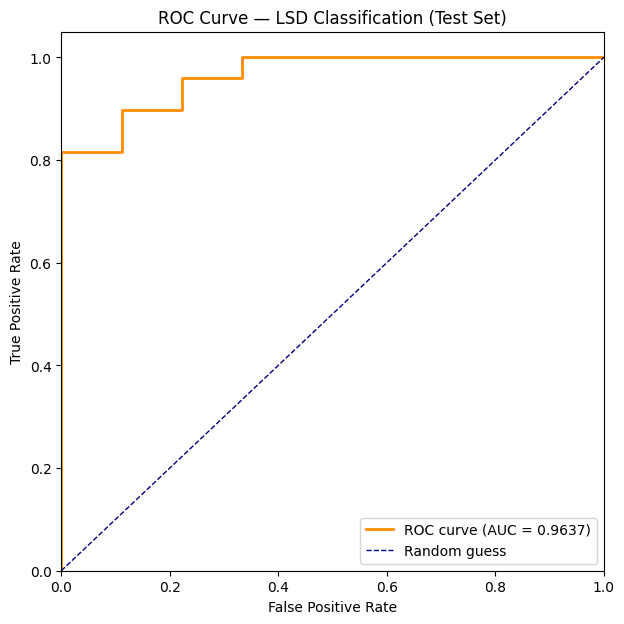

AUC: 0.9637
Saved to: /content/drive/MyDrive/LSD_Detection_Project/resnet50_classification/roc_curve.png


In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — LSD Classification (Test Set)')
plt.legend(loc='lower right')

roc_path = os.path.join(RESNET_RUN_DIR, "roc_curve.png")
plt.savefig(roc_path, dpi=150)
plt.show()

print(f"AUC: {roc_auc:.4f}")
print(f"Saved to: {roc_path}")

## 14. Full training summary (saved to Drive)

In [ ]:
summary_path = os.path.join(RESNET_RUN_DIR, "training_summary.txt")

with open(summary_path, "w") as f:
    f.write("RESNET50 LSD CLASSIFICATION — TRAINING SUMMARY\n")
    f.write("=" * 55 + "\n\n")
    f.write(f"Phase 1 epochs: {len(history1.history['accuracy'])}\n")
    f.write(f"Phase 2 (fine-tune) epochs: {len(history2.history['accuracy'])}\n\n")
    f.write("TEST SET RESULTS:\n")
    for name, value in zip(metric_names, test_results):
        f.write(f"  {name}: {value:.4f}\n")
    f.write(f"\n  ROC AUC: {roc_auc:.4f}\n\n")
    f.write("CLASSIFICATION REPORT:\n")
    f.write(report)

print("Summary saved to:", summary_path)

with open(summary_path) as f:
    print("\n" + f.read())

Summary saved to: /content/drive/MyDrive/LSD_Detection_Project/resnet50_classification/training_summary.txt

RESNET50 LSD CLASSIFICATION — TRAINING SUMMARY

Phase 1 epochs: 27
Phase 2 (fine-tune) epochs: 16

TEST SET RESULTS:
  loss: 0.1793
  compile_metrics: 0.9310

  ROC AUC: 0.9637

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     Healthy       0.86      0.67      0.75         9
LSD-Positive       0.94      0.98      0.96        49

    accuracy                           0.93        58
   macro avg       0.90      0.82      0.85        58
weighted avg       0.93      0.93      0.93        58



## 15. Test on your own images
Upload an image and get the LSD probability with the risk guidance thresholds from your proposal (Section 3.6):
- **0–30%**: Low risk
- **30–70%**: Moderate risk
- **70–100%**: High risk

Saving Lumpy_Skin_301.png to Lumpy_Skin_301 (1).png

--- Lumpy_Skin_301 (1).png ---
LSD Probability: 100.0%
Risk Level: HIGH RISK
Guidance: Immediate veterinary consultation strongly advised. Isolate the animal from the herd.


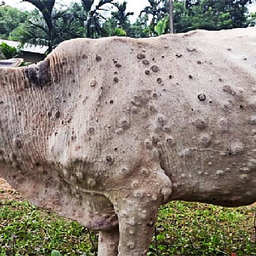

In [ ]:
from google.colab import files
from IPython.display import Image as IPImage, display
import numpy as np

def classify_image(img_path, model):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img_input = tf.keras.applications.resnet50.preprocess_input(img)
    img_input = tf.expand_dims(img_input, axis=0)

    prob = float(model.predict(img_input, verbose=0)[0][0])
    return prob

def risk_guidance(prob):
    pct = prob * 100
    if pct < 30:
        return "LOW RISK", "Continue monitoring. Maintain regular health checks."
    elif pct < 70:
        return "MODERATE RISK", "Isolate the animal and monitor closely. Consider consulting a veterinarian."
    else:
        return "HIGH RISK", "Immediate veterinary consultation strongly advised. Isolate the animal from the herd."

uploaded = files.upload()

for filename in uploaded.keys():
    prob = classify_image(filename, best_model)
    risk_level, guidance = risk_guidance(prob)

    print(f"\n--- {filename} ---")
    print(f"LSD Probability: {prob*100:.1f}%")
    print(f"Risk Level: {risk_level}")
    print(f"Guidance: {guidance}")

    display(IPImage(filename=filename, width=400))

## Notes
- Best model weights saved at: `LSD_Detection_Project/resnet50_classification/resnet50_lsd_best.keras`
- This notebook classifies **full images**, not YOLOv8-cropped regions — a simpler but still valid approach per your earlier decision. If you later want to more closely match your proposal's literal crop-then-classify pipeline (Section 3.2.4), that would mean running your trained YOLOv8 model over each training image first to extract nodule crops, then retraining ResNet50 on those crops instead of full images — a reasonable future extension, not required for this to work.
- If test accuracy/AUC seems lower than expected, the same diagnostic principles from the YOLOv8 notebook apply: check annotation/labeling consistency between your Lumpy Skin and Normal Skin folders, and consider whether more training images would help.
